# 01 — Data Quality e decisões de tratamento

## Objetivo deste notebook
Inspecionar a qualidade da fonte antes das transformações para justificar, com evidência, cada decisão aplicada no data pipeline medalhão (bronze -> silver -> gold).

## Como este notebook se conecta ao pipeline
- Este notebook é a camada explicativa e de auditoria; a execução das regras fica centralizada em `src/ifood_analytics/quality.py`.
- Os data contracts importados aqui (schema, keys e date columns monitoradas) são os mesmos usados no data quality gate do pipeline.
- Assim, narrativa e execução permanecem alinhadas: mudança no contrato do script se reflete na análise.

## O que é verificado
- Schema dos 09 CSVs: colunas esperadas por tabela.
- Integridade de chaves: unicidade e não nulidade nas candidate keys.
- Integridade referencial: FKs entre pedidos, clientes, itens, produtos, sellers, pagamentos e reviews.
- Domínios e temporal consistency: status válidos e ordem lógica entre datas.
- Reconciliation financeira: comparação entre pagamentos e itens+frete com agregação prévia por pedido.
- Outliers e geolocalização: monitoramento de caudas e risco de fan-out por CEP.

## Decisões de tratamento justificadas
- Categoria ausente em produtos: classificar como `unknown` e manter rastreabilidade da ausência original.
- Geolocalização: consolidar visão por CEP com mediana (lat/lng) e moda (cidade/UF), sem perder a tabela detalhada.
- Outliers de preço/frete: preservar valores e monitorar prevalência, evitando distorção de GMV.
- Pagamentos e reviews: agregar por `order_id` antes de joins com itens para evitar produto cartesiano.
- Nulos condicionais do ciclo do pedido: preservar semantically valid nulls e não fabricar datas.

## Critérios de decisão no gate
- Critical checks: bloqueiam publicação da gold quando reprovam.
- Warning checks: não bloqueiam, mas permanecem visíveis para monitoring operacional.

## Limitações e interpretação
- Este notebook valida quality e consistência estrutural; não infere causalidade de negócio.
- GMV é proxy comercial de receita bruta de itens, não receita líquida/margem.
- Alertas tolerados continuam documentados para governança e revisão periódica.

In [1]:
from pathlib import Path
import os, sys
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, str(Path.cwd().parent / 'src'))
from ifood_analytics.quality import (
    EXPECTED_COLUMNS,
    KEY_CONTRACTS,
    ORDER_DATE_COLUMNS,
    run_quality_checks,
    )
_ = (EXPECTED_COLUMNS, KEY_CONTRACTS, ORDER_DATE_COLUMNS)
SOURCE = Path(os.getenv('OLIST_SOURCE', '../data/bronze'))
assert SOURCE.exists(), 'Execute o pipeline ou defina OLIST_SOURCE para a pasta dos CSVs.'

### Rastreabilidade das regras do pipeline
Este notebook mantém a explicação analítica e importa os contratos do `quality.py`, garantindo que os mesmos critérios usados no pipeline sejam auditados aqui.

Com isso, evitamos divergência entre narrativa e execução: se o contrato mudar no script, a auditoria do notebook reflete a mudança imediatamente.

In [2]:
contract_snapshot = pd.DataFrame([
    {
        'arquivo_csv': name,
        'colunas_esperadas': len(columns),
    }
    for name, columns in EXPECTED_COLUMNS.items()
 ]).sort_values('arquivo_csv')

key_snapshot = pd.DataFrame([
    {
        'contrato_chave': contract_name,
        'arquivo_csv': table_name,
        'colunas_chave': ', '.join(columns),
    }
    for contract_name, (table_name, columns) in KEY_CONTRACTS.items()
]).sort_values('contrato_chave')

display(contract_snapshot)
display(key_snapshot)
pd.Series({
    'total_contratos_schema': len(EXPECTED_COLUMNS),
    'total_contratos_chave': len(KEY_CONTRACTS),
    'colunas_data_pedido_monitoradas': ', '.join(ORDER_DATE_COLUMNS),
}).to_frame('valor')

,arquivo_csv,colunas_esperadas
0,olist_customers_dataset.csv,5
1,olist_geolocation_dataset.csv,5
2,olist_order_items_dataset.csv,7
3,olist_order_payments_dataset.csv,5
4,olist_order_reviews_dataset.csv,7
5,olist_orders_dataset.csv,8
6,olist_products_dataset.csv,9
7,olist_sellers_dataset.csv,4
8,product_category_name_translation.csv,2


,contrato_chave,arquivo_csv,colunas_chave
1,customers.customer_id,olist_customers_dataset.csv,customer_id
2,items.order_id+item_id,olist_order_items_dataset.csv,"order_id, order_item_id"
0,orders.order_id,olist_orders_dataset.csv,order_id
3,payments.order_id+sequence,olist_order_payments_dataset.csv,"order_id, payment_sequential"
4,products.product_id,olist_products_dataset.csv,product_id
5,sellers.seller_id,olist_sellers_dataset.csv,seller_id
6,translation.category,product_category_name_translation.csv,product_category_name


,valor
total_contratos_schema,9
total_contratos_chave,7
colunas_data_pedido_monitoradas,"order_purchase_timestamp, order_approved_at, o..."


**Qualidade Geral dos Dados**

In [3]:
profiles = []
frames = {}
for file in sorted(SOURCE.glob('*.csv')):
    df = pd.read_csv(file, low_memory=False)
    frames[file.name] = df
    profiles.append({'tabela': file.stem, 'linhas': len(df), 'colunas': df.shape[1], 'linhas_duplicadas': int(df.duplicated().sum()), 'perc_nulas': df.isna().mean().mean()})
pd.DataFrame(profiles).style.format({'perc_nulas': '{:.2%}'})

,tabela,linhas,colunas,linhas_duplicadas,perc_nulas
0,olist_customers_dataset,99441,5,0,0.00%
1,olist_geolocation_dataset,1000163,5,261831,0.00%
2,olist_order_items_dataset,112650,7,0,0.00%
3,olist_order_payments_dataset,103886,5,0,0.00%
4,olist_order_reviews_dataset,99224,7,0,21.01%
5,olist_orders_dataset,99441,8,0,0.62%
6,olist_products_dataset,32951,9,0,0.83%
7,olist_sellers_dataset,3095,4,0,0.00%
8,product_category_name_translation,71,2,0,0.00%


**Nulos e duplicatas**

Observações: comentários de review são opcionais e datas futuras do ciclo do pedido dependem do status.

In [4]:
nulls = []
for table, df in frames.items():
    for column, count in df.isna().sum().items():
        if count:
            nulls.append({'CSV': table, 'coluna': column, 'nulo': count, 'perc': count / len(df)})
pd.DataFrame(nulls).sort_values('perc', ascending=False).style.format({'perc': '{:.2%}'})

,CSV,coluna,nulo,perc
0,olist_order_reviews_dataset.csv,review_comment_title,87656,88.34%
1,olist_order_reviews_dataset.csv,review_comment_message,58247,58.70%
4,olist_orders_dataset.csv,order_delivered_customer_date,2965,2.98%
6,olist_products_dataset.csv,product_name_lenght,610,1.85%
5,olist_products_dataset.csv,product_category_name,610,1.85%
7,olist_products_dataset.csv,product_description_lenght,610,1.85%
8,olist_products_dataset.csv,product_photos_qty,610,1.85%
3,olist_orders_dataset.csv,order_delivered_carrier_date,1783,1.79%
2,olist_orders_dataset.csv,order_approved_at,160,0.16%
9,olist_products_dataset.csv,product_weight_g,2,0.01%


In [5]:
geo = frames['olist_geolocation_dataset.csv']
pd.Series({'rows': len(geo), 'full_duplicates': geo.duplicated().sum(), \
           'unique_zip_codes': geo.geolocation_zip_code_prefix.nunique()})

rows                1000163
full_duplicates      261831
unique_zip_codes      19015
dtype: int64

- Dentro do dataset de produtos, exite a coluna product_category_name que contém linhas vazias, ao invés de apenas excluir, assim perdendo informação. Foi definido classificar como `unknown` até ter uma idefinição exata para corrigir a classificação.
- Geolocalização é consolidada por CEP com mediana das coordenadas e moda de cidade/UF, evitando multiplicação em joins.

**Checks automatizados de qualidade**

Checks críticos bloqueiam o pipeline; warnings documentam anomalias toleradas.

In [6]:
checks = pd.DataFrame(run_quality_checks(SOURCE))
checks[['check', 'passed', 'observed', 'expectation', 'severity']].style \
    .applymap(lambda x: 'color: green' if x is True else ('color: red' if x is False else ''), subset=['passed'])

C:\Users\Computador\AppData\Local\Temp\ipykernel_804\436522419.py:3: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: 'color: green' if x is True else ('color: red' if x is False else ''), subset=['passed'])


,check,passed,observed,expectation,severity
0,schema olist_customers_dataset.csv,True,"{'missing': [], 'unexpected': []}",colunas exatamente iguais ao contrato,critical
1,schema olist_geolocation_dataset.csv,True,"{'missing': [], 'unexpected': []}",colunas exatamente iguais ao contrato,critical
2,schema olist_order_items_dataset.csv,True,"{'missing': [], 'unexpected': []}",colunas exatamente iguais ao contrato,critical
3,schema olist_order_payments_dataset.csv,True,"{'missing': [], 'unexpected': []}",colunas exatamente iguais ao contrato,critical
4,schema olist_order_reviews_dataset.csv,True,"{'missing': [], 'unexpected': []}",colunas exatamente iguais ao contrato,critical
5,schema olist_orders_dataset.csv,True,"{'missing': [], 'unexpected': []}",colunas exatamente iguais ao contrato,critical
6,schema olist_products_dataset.csv,True,"{'missing': [], 'unexpected': []}",colunas exatamente iguais ao contrato,critical
7,schema olist_sellers_dataset.csv,True,"{'missing': [], 'unexpected': []}",colunas exatamente iguais ao contrato,critical
8,schema product_category_name_translation.csv,True,"{'missing': [], 'unexpected': []}",colunas exatamente iguais ao contrato,critical
9,orders.order_id único e preenchido,True,"{'duplicates': 0, 'null_keys': 0}",0 duplicatas e 0 chaves nulas,critical


### Leitura executiva do gate de qualidade
Separar críticos de warnings mostra exatamente o que bloqueia a publicação da gold e o que segue como monitoramento contínuo.

In [7]:
critical = checks.query("severity == 'critical'").copy()
warning = checks.query("severity == 'warning'").copy()

summary = pd.DataFrame([
    {'camada': 'critical', 'total': len(critical), 'reprovados': int((~critical.passed).sum())},
    {'camada': 'warning', 'total': len(warning), 'reprovados': int((~warning.passed).sum())},
])
display(summary)

display(
    critical.loc[~critical.passed, ['check', 'observed', 'expectation']].reset_index(drop=True)
    if (~critical.passed).any()
    else pd.DataFrame({'status': ['Nenhum check crítico reprovado.']})
)

display(
    warning.loc[~warning.passed, ['check', 'observed', 'expectation']].reset_index(drop=True)
    if (~warning.passed).any()
    else pd.DataFrame({'status': ['Nenhum warning aberto.']})
)

,camada,total,reprovados
0,critical,29,0
1,warning,6,3


,status
0,Nenhum check crítico reprovado.


,check,observed,expectation
0,outliers extremos de preço/frete monitorados,"{'price': 4074, 'freight_value': 5538, 'row_ra...",menos de 5% das linhas acima de Q3 + 3*IQR; pr...
1,coordenadas em faixa geográfica plausível,29,0 coordenadas fora da faixa ampla do Brasil
2,pagamentos reconciliam itens + frete,"{'only_payments': 775, 'only_items': 1, 'compa...",menos de 2% de divergência nos pedidos compará...


**Outliers de preço e frete**

Valores altos são sinalizados, não removidos: sem regra de negócio ou evidência de erro, truncá-los distorceria receita.

In [8]:
items = frames['olist_order_items_dataset.csv']
items[['price', 'freight_value']].describe(percentiles=[.05, .1, .2, .3, .4, .5, .6, .7, .8, .9, .95]).T

,count,mean,std,min,5%,10%,20%,30%,40%,50%,60%,70%,80%,90%,95%,max
price,112650.0,120.653739,183.633928,0.85,17.00,23.80,34.90,47.49,59.00,74.99,95.00,119.90,150.00,229.800,349.90,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,7.78,8.73,12.12,14.02,15.11,16.26,17.87,19.41,23.28,34.041,45.12,409.68


In [9]:
items = frames['olist_order_items_dataset.csv']
items[['price', 'freight_value']].describe(percentiles=[.5, .9, .95, .99, .999]).T

,count,mean,std,min,50%,90%,95%,99%,99.9%,max
price,112650.0,120.653739,183.633928,0.85,74.99,229.800,349.90,890.00,2110.00000,6735.00
freight_value,112650.0,19.990320,15.806405,0.00,16.26,34.041,45.12,84.52,175.59212,409.68


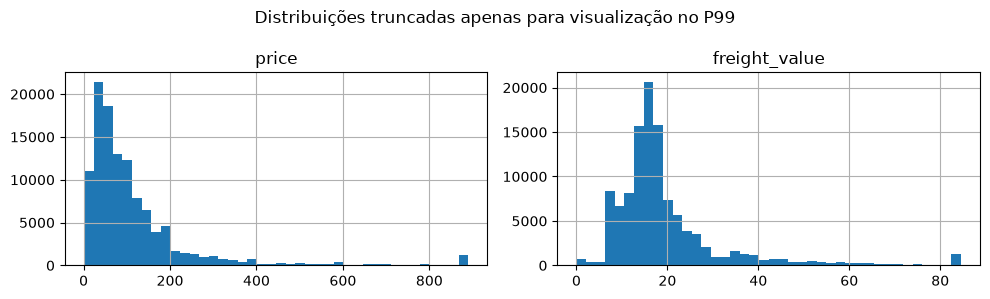

In [10]:
items[['price', 'freight_value']].clip(upper=items[['price', 'freight_value']].quantile(.99), axis=1).hist(bins=40, figsize=(10, 3));
plt.suptitle('Distribuições truncadas apenas para visualização no P99'); plt.tight_layout()

**Granularidade e chaves candidatas**

A ausência de duplicata de linha não garante unicidade da chave. A tabela abaixo testa o grão declarado de cada entidade e diferencia `customer_id` (um pedido) de `customer_unique_id` (pessoa ao longo do tempo).

In [11]:
key_contracts = {
    'orders.order_id': (frames['olist_orders_dataset.csv'], ['order_id']),
    'customers.customer_id': (frames['olist_customers_dataset.csv'], ['customer_id']),
    'items.order_id+item_id': (frames['olist_order_items_dataset.csv'], ['order_id','order_item_id']),
    'payments.order_id+sequence': (frames['olist_order_payments_dataset.csv'], ['order_id','payment_sequential']),
    'products.product_id': (frames['olist_products_dataset.csv'], ['product_id']),
    'sellers.seller_id': (frames['olist_sellers_dataset.csv'], ['seller_id']),
}
key_profile = pd.DataFrame([{'contract': name, 'rows': len(df), 'duplicate_keys': int(df.duplicated(keys).sum()), 'null_keys': int(df[keys].isna().any(axis=1).sum())} for name, (df, keys) in key_contracts.items()])
display(key_profile)
customers = frames['olist_customers_dataset.csv']
pd.Series({'customer_ids': customers.customer_id.nunique(), 'unique_people': customers.customer_unique_id.nunique(), 'people_with_multiple_customer_ids': int(customers.groupby('customer_unique_id').customer_id.nunique().gt(1).sum())})

,contract,rows,duplicate_keys,null_keys
0,orders.order_id,99441,0,0
1,customers.customer_id,99441,0,0
2,items.order_id+item_id,112650,0,0
3,payments.order_id+sequence,103886,0,0
4,products.product_id,32951,0,0
5,sellers.seller_id,3095,0,0


customer_ids                         99441
unique_people                        96096
people_with_multiple_customer_ids     2997
dtype: int64

**Nulidade condicionada ao ciclo do pedido**

Datas de entrega avaliadas por status

In [12]:
orders_raw = frames['olist_orders_dataset.csv'].copy()
date_cols = ['order_approved_at','order_delivered_carrier_date','order_delivered_customer_date']
status_completeness = orders_raw.groupby('order_status')[date_cols].agg(lambda s: s.notna().mean()) \
    .join(orders_raw.groupby('order_status').size().rename('orders'))
status_completeness.sort_values('orders', ascending=False).style.format({column: '{:.2%}' for column in date_cols})

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,orders
order_status,,,,
delivered,99.99%,100.00%,99.99%,96478
shipped,100.00%,100.00%,0.00%,1107
canceled,77.44%,12.00%,0.96%,625
unavailable,100.00%,0.00%,0.00%,609
invoiced,100.00%,0.00%,0.00%,314
processing,100.00%,0.00%,0.00%,301
created,0.00%,0.00%,0.00%,5
approved,100.00%,0.00%,0.00%,2


**Coerência temporal e distribuição dos tempos**

Além de procurar datas invertidas, observamos as caudas dos tempos de aprovação e entrega. Cauda longa pode ser operacionalmente relevante sem ser erro de dados.

In [13]:
orders_t = orders_raw.copy()
all_dates = ['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date', \
             'order_delivered_customer_date','order_estimated_delivery_date']
for column in all_dates: orders_t[column] = pd.to_datetime(orders_t[column], errors='coerce')
orders_t['approval_hours'] = (orders_t.order_approved_at - orders_t.order_purchase_timestamp).dt.total_seconds() / 3600
orders_t['delivery_days'] = (orders_t.order_delivered_customer_date - orders_t.order_purchase_timestamp).dt.total_seconds() / 86400
orders_t['delay_days'] = (orders_t.order_delivered_customer_date - orders_t.order_estimated_delivery_date).dt.total_seconds() / 86400
display(orders_t[['approval_hours','delivery_days','delay_days']].describe(percentiles=[.5,.9,.95,.99,.999]).T)
pd.Series({'approval_before_purchase': int(orders_t.approval_hours.lt(0).sum()), \
           'delivery_before_purchase': int(orders_t.delivery_days.lt(0).sum()), \
            'delivered_missing_date': int(orders_t.order_status.eq('delivered').mul(orders_t.order_delivered_customer_date.isna()).sum())})

,count,mean,std,min,50%,90%,95%,99%,99.9%,max
approval_hours,99281.0,10.419094,26.038004,0.000000,0.343333,34.659722,48.463611,90.166500,154.338544,4509.180556
delivery_days,96476.0,12.558702,9.546530,0.533414,10.217755,23.097604,29.276016,46.049913,83.139489,209.628611
delay_days,96476.0,-11.179120,10.186113,-146.016123,-11.948941,-1.137517,3.818458,18.939306,55.692328,188.975081


approval_before_purchase    0
delivery_before_purchase    0
delivered_missing_date      8
dtype: int64

**Pagamentos**

Pagamentos têm múltiplas linhas por pedido. Primeiro agregamos pagamentos e itens separadamente; só então comparamos `payment_value` com preço + frete, evitando fan-out.

In [14]:
payments = frames['olist_order_payments_dataset.csv'].groupby('order_id', as_index=False).payment_value.sum()
item_totals = items.groupby('order_id', as_index=False).agg(price=('price','sum'), freight=('freight_value','sum'))
recon = payments.merge(item_totals, on='order_id', how='outer', indicator=True)
recon['difference'] = recon.payment_value - recon.price - recon.freight
display(recon.difference.abs().describe(percentiles=[.5,.9,.95,.99,.999]).to_frame('absolute_difference'))
pd.Series({'orders_compared': len(recon), 'missing_on_one_side': int(recon._merge.ne('both').sum()), 'difference_gt_1_cent': int(recon.difference.abs().gt(.01).sum()), 'difference_gt_1_real': int(recon.difference.abs().gt(1).sum())})

,absolute_difference
count,9.866500e+04
mean,3.316222e-02
std,1.129109e+00
min,0.000000e+00
50%,3.552714e-15
90%,1.776357e-14
95%,2.842171e-14
99%,8.526513e-14
99.9%,9.933600e+00
max,1.828100e+02


orders_compared         99441
missing_on_one_side       776
difference_gt_1_cent      417
difference_gt_1_real      250
dtype: int64

**Sensibilidade a outliers**

O volume de outliers e sua participação na receita são medidas distintas. Remover caudas pode afetar pouco as linhas, mas muito o valor financeiro.

In [15]:
extreme = pd.Series(False, index=items.index)
thresholds = {}
for column in ['price','freight_value']:
    q1, q3 = items[column].quantile([.25,.75]); thresholds[column] = q3 + 3*(q3-q1)
    extreme |= items[column].gt(thresholds[column])
pd.Series({'extreme_row_rate': extreme.mean(), \
           'extreme_price_revenue_share': items.loc[extreme,'price'].sum()/items.price.sum(), \
            'extreme_freight_share': items.loc[extreme,'freight_value'].sum()/items.freight_value.sum(), \
            **{f'{k}_threshold':v for k,v in thresholds.items()}}).to_frame('value')

,value
extreme_row_rate,0.074106
extreme_price_revenue_share,0.306247
extreme_freight_share,0.207938
price_threshold,419.900000
freight_value_threshold,45.360000


**Geolocalização e risco de fan-out**

Um CEP possui várias observações e, às vezes, grafias de cidade ou coordenadas atípicas. O diagnóstico mede a ambiguidade antes da consolidação por mediana/moda.

In [16]:
zip_profile = geo.groupby('geolocation_zip_code_prefix')\
    .agg(rows=('geolocation_lat','size'), \
         cities=('geolocation_city','nunique'), \
            states=('geolocation_state','nunique'), \
                lat_span=('geolocation_lat', lambda s: s.max()-s.min()), \
                    lng_span=('geolocation_lng', lambda s: s.max()-s.min()))
pd.Series({'zip_codes': len(zip_profile), \
           'zip_with_multiple_cities': int(zip_profile.cities.gt(1).sum()), \
            'zip_with_multiple_states': int(zip_profile.states.gt(1).sum()), \
                'max_rows_per_zip': int(zip_profile.rows.max()), \
                    'coordinates_outside_broad_brazil_box': int((~geo.geolocation_lat.between(-35,6) | ~geo.geolocation_lng.between(-75,-30)).sum())})

zip_codes                               19015
zip_with_multiple_cities                 8556
zip_with_multiple_states                    8
max_rows_per_zip                         1146
coordinates_outside_broad_brazil_box       29
dtype: int64

### Ponte entre achado e tratamento aplicado
A tabela abaixo documenta por que cada tratamento existe no pipeline e qual risco ele controla no case.

In [17]:
treatment_rationale = pd.DataFrame([
    {
        'achado': 'product_category_name com ausência',
        'tratamento_pipeline': 'preencher category como unknown e manter flag de ausência',
        'por_que': 'preserva GMV e mantém rastreabilidade da perda de informação original',
    },
    {
        'achado': 'geolocalização com múltiplas linhas por CEP',
        'tratamento_pipeline': 'criar visão por CEP com mediana (lat/lng) e moda (cidade/UF)',
        'por_que': 'evita fan-out em joins sem apagar a tabela detalhada',
    },
    {
        'achado': 'outliers de price/freight',
        'tratamento_pipeline': 'preservar valores e monitorar prevalência',
        'por_que': 'remoção de caudas distorce receita e frete',
    },
    {
        'achado': 'pagamentos/reviews com múltiplas linhas por pedido',
        'tratamento_pipeline': 'agregar por order_id antes dos joins com itens',
        'por_que': 'impede produto cartesiano e duplicação de GMV',
    },
    {
        'achado': 'nulos condicionados ao status do pedido',
        'tratamento_pipeline': 'não imputar datas de entrega quando o ciclo não exige entrega',
        'por_que': 'evita fabricar eventos e respeita semântica operacional',
    },
])
display(treatment_rationale)

,achado,tratamento_pipeline,por_que
0,product_category_name com ausência,preencher category como unknown e manter flag ...,preserva GMV e mantém rastreabilidade da perda...
1,geolocalização com múltiplas linhas por CEP,criar visão por CEP com mediana (lat/lng) e mo...,evita fan-out em joins sem apagar a tabela det...
2,outliers de price/freight,preservar valores e monitorar prevalência,remoção de caudas distorce receita e frete
3,pagamentos/reviews com múltiplas linhas por pe...,agregar por order_id antes dos joins com itens,impede produto cartesiano e duplicação de GMV
4,nulos condicionados ao status do pedido,não imputar datas de entrega quando o ciclo nã...,evita fabricar eventos e respeita semântica op...


## **Conclusão e contrato de tratamento**
A fonte tem boa integridade de chaves e domínios: as seis chaves candidatas testadas não têm duplicatas/nulos e não há datas de aprovação/entrega anteriores à compra. Há, porém, 8 pedidos `delivered` sem data de entrega. 

Os 7,41% itens sinalizados como extremos concentram 30,62% da receita de produtos e 20,79% do frete, portanto removê-los distorceria os dados. Na reconciliação, 417 pedidos diferem mais de R$ 0,01 e 776 existem em apenas um dos lados do outer join. 

Geolocalização contém 8.556 CEPs associados a múltiplas grafias de cidade, 8 a mais de uma UF e 29 coordenadas fora da faixa ampla. 

O pipeline deve tipar datas, normalizar espaços, usar categoria `unknown`, agregar entidades antes dos joins e consolidar CEP. Nulos semânticos e outliers são preservados; críticos bloqueiam a carga e warnings permanecem observáveis no relatório.